# Homework 11 — Evaluation & Risk Communication
In the lecture, we learned **gaussian-based vs bootstrap-based CIs**, **scenario sensitivity**, and **subgroup checks**.
Now, you will adapt those methods to your dataset and produce assumption-aware results.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from src.evaluation import (SimpleLinReg, mean_impute, median_impute, mae,
                            bootstrap_metric, bootstrap_predictions)
np.random.seed(111)
plt.rcParams['figure.figsize'] = (8,5)

## Load Data (provided or synthetic fallback)

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

data_dir = Path('data/raw')
data_dir.mkdir(parents=True, exist_ok=True)

csv_path = data_dir / 'data_stage11_eval_risk.csv'

if csv_path.exists():
    try:
        df = pd.read_csv(csv_path, parse_dates=['date'])
    except ValueError as e:
        print(f"Error reading CSV: {e}\nRegenerating synthetic data...")
        regenerate = True
    else:
        regenerate = False
else:
    regenerate = True

if regenerate:
    n = 180
    dates = pd.date_range('2022-06-01', periods=n, freq='D')
    seg = np.random.choice(['A','B','C'], size=n, p=[0.5,0.3,0.2])
    x = np.linspace(0, 9, n) + np.random.normal(0, 0.7, n)
    y = 2.1 * x + 0.8 + np.random.standard_t(df=3, size=n) * 1.1
    x[np.random.choice(np.arange(n), size=round(0.05*n), replace=False)] = np.nan
    df = pd.DataFrame({'date': dates, 'segment': seg, 'x_feature': x, 'y_target': y})
    df.to_csv(csv_path, index=False)

df.head()


,date,segment,x_feature,y_target
0,2022-06-01,B,0.547868,2.107524
1,2022-06-02,A,0.974480,2.209111
2,2022-06-03,A,-0.012991,0.867315
3,2022-06-04,B,-1.012503,-1.741932
4,2022-06-05,A,0.642399,1.615007


## Reusable helper functions
The imputation, regression, MAE, and bootstrap functions are stored in `src/evaluation.py` and imported above so the analysis is reproducible and reusable.

In [4]:
# Confirm that the helper module is available.
print('Loaded reusable evaluation helpers from src/evaluation.py')

Loaded reusable evaluation helpers from src/evaluation.py


## Baseline Fit & Residuals (Required)

In [5]:
X_raw = df['x_feature'].values
y = df['y_target'].values
X_base = mean_impute(X_raw)
model = SimpleLinReg().fit(X_base.reshape(-1,1), y)
y_hat = model.predict(X_base.reshape(-1,1))
df['x_imputed'] = X_base
base_mae = mae(y, y_hat)
print(f'Baseline MAE: {base_mae:.3f}')
print(f'Baseline slope: {model.coef_[0]:.3f}; intercept: {model.intercept_:.3f}')

Baseline MAE: 1.278
Baseline slope: 2.130; intercept: 0.712


## Gaussian-based vs Bootstrap-based CI (Required)

Average Gaussian CI width: 0.920
Average bootstrap CI width: 0.791


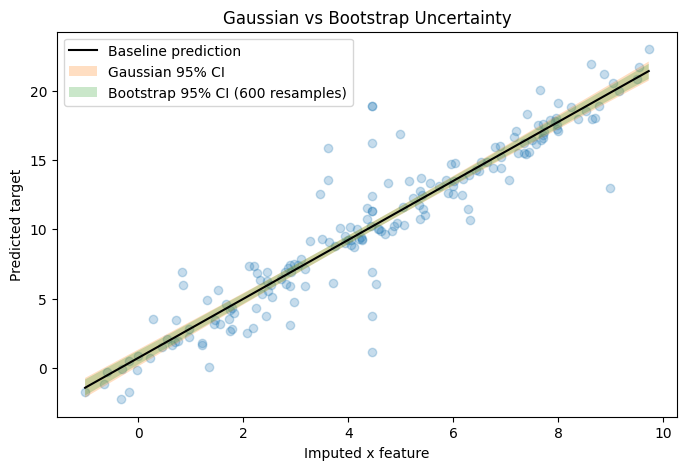

In [6]:
resid = y - y_hat
sigma_hat = np.sqrt(np.sum(resid ** 2) / (len(y) - 2))
n = len(y)
x_grid = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 120).reshape(-1,1)
pred_line = model.predict(x_grid)
x_mean = X_base.mean()
sxx = np.sum((X_base - x_mean) ** 2)
se_mean = sigma_hat * np.sqrt(1/n + (x_grid.ravel() - x_mean) ** 2 / sxx)
gauss_lo = pred_line - 1.96 * se_mean
gauss_hi = pred_line + 1.96 * se_mean

m_boot, lo_boot, hi_boot = bootstrap_predictions(X_base, y, x_grid, n_boot=600)
print(f'Average Gaussian CI width: {np.mean(gauss_hi - gauss_lo):.3f}')
print(f'Average bootstrap CI width: {np.mean(hi_boot - lo_boot):.3f}')

plt.figure()
plt.scatter(X_base, y, alpha=0.25)
plt.plot(x_grid, pred_line, color='black', label='Baseline prediction')
plt.fill_between(x_grid.ravel(), gauss_lo, gauss_hi, alpha=0.25, label='Gaussian 95% CI')
plt.fill_between(x_grid.ravel(), lo_boot, hi_boot, alpha=0.25, label='Bootstrap 95% CI (600 resamples)')
plt.xlabel('Imputed x feature')
plt.ylabel('Predicted target')
plt.legend(); plt.title('Gaussian vs Bootstrap Uncertainty'); plt.show()

## Scenario Sensitivity (Required): Choose ≥2 Scenarios
Examples: mean vs median impute; drop; alternate feature transform

In [7]:
observed = ~np.isnan(X_raw)
scenario_data = {
    'Mean imputation': (mean_impute(X_raw), y),
    'Median imputation': (median_impute(X_raw), y),
    'Drop missing rows': (X_raw[observed], y[observed]),
}

results, scenario_models = [], {}
for name, (Xs, ys) in scenario_data.items():
    m = SimpleLinReg().fit(Xs.reshape(-1, 1), ys)
    yh = m.predict(Xs.reshape(-1, 1))
    ci = bootstrap_metric(ys, yh, mae, n_boot=600, seed=111)
    scenario_models[name] = m
    results.append({'scenario': name, 'n': len(ys), 'mae': ci['estimate'],
                    'mae_ci_lo': ci['lo'], 'mae_ci_hi': ci['hi'],
                    'slope': m.coef_[0], 'intercept': m.intercept_})
sens = pd.DataFrame(results)

# Save the scenario table - this is your sensitivity
# evidence, and what your Stage 12 stakeholder report is built from.
Path('data/processed').mkdir(parents=True, exist_ok=True)
sens.to_csv('data/processed/scenario_results.csv', index=False)
sens

,scenario,n,mae,mae_ci_lo,mae_ci_hi,slope,intercept
0,Mean imputation,180,1.278317,1.055082,1.530998,2.130236,0.711523
1,Median imputation,180,1.283954,1.061979,1.532868,2.129290,0.727146
2,Drop missing rows,171,1.064603,0.906036,1.240116,2.130236,0.659164


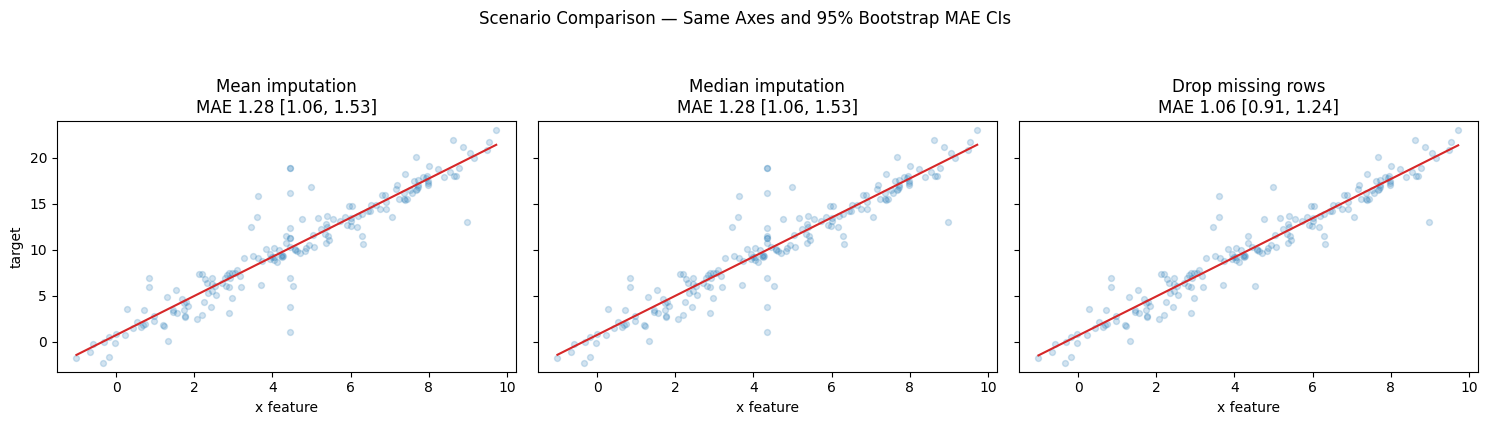

In [8]:
xg = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 150).reshape(-1,1)
x_limits = (X_base.min() - 0.5, X_base.max() + 0.5)
y_limits = (y.min() - 1, y.max() + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (name, (Xs, ys)) in zip(axes, scenario_data.items()):
    m = scenario_models[name]
    row = sens.loc[sens['scenario'] == name].iloc[0]
    ax.scatter(Xs, ys, alpha=0.20, s=18)
    ax.plot(xg, m.predict(xg), color='tab:red')
    ax.set_title(f"{name}\nMAE {row.mae:.2f} [{row.mae_ci_lo:.2f}, {row.mae_ci_hi:.2f}]")
    ax.set_xlim(x_limits); ax.set_ylim(y_limits); ax.set_xlabel('x feature')
axes[0].set_ylabel('target')
fig.suptitle('Scenario Comparison — Same Axes and 95% Bootstrap MAE CIs', y=1.05)
plt.tight_layout(); plt.show()

## Subgroup Diagnostic (Required)

In [9]:
model_base = SimpleLinReg().fit(X_base.reshape(-1,1), y)
df2 = df.copy()
df2['y_hat'] = model_base.predict(df2['x_imputed'].values.reshape(-1,1))
df2['resid'] = df2['y_target'] - df2['y_hat']
df2['abs_error'] = np.abs(df2['resid'])
g = df2.groupby('segment').agg(
    count=('resid', 'size'),
    bias=('resid', 'mean'),
    residual_std=('resid', 'std'),
    mae=('abs_error', 'mean')
)
g

,count,bias,residual_std,mae
segment,,,,
A,94,-0.066306,1.827501,1.141841
B,41,0.294967,1.707514,0.989357
C,45,-0.130242,2.813215,1.826674


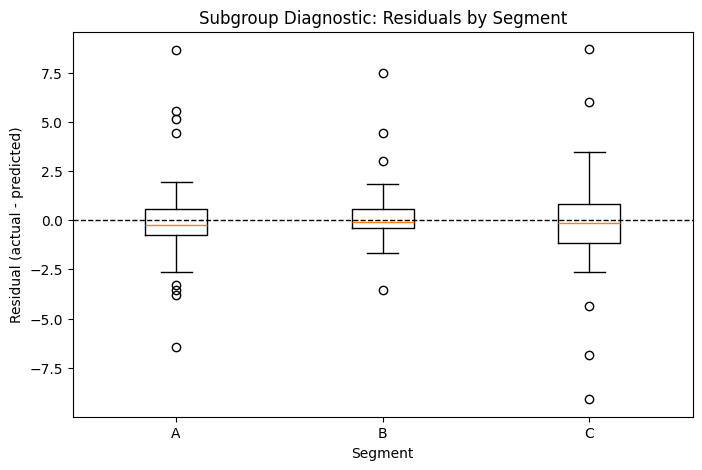

In [10]:
plt.figure()
grouped = df2.groupby('segment')['resid']
data = [s.values for _, s in grouped]
labels = list(grouped.groups.keys())

# NOT tick_labels= and NOT labels= - both spellings are version-locked. Setting the
# ticks separately works on every matplotlib.
plt.boxplot(data)
plt.xticks(range(1, len(labels) + 1), labels)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Segment')
plt.ylabel('Residual (actual - predicted)')
plt.title('Subgroup Diagnostic: Residuals by Segment')
plt.show()


## Bootstrap a Metric (Required)

MAE = 1.278; 95% bootstrap CI = [1.055, 1.531]


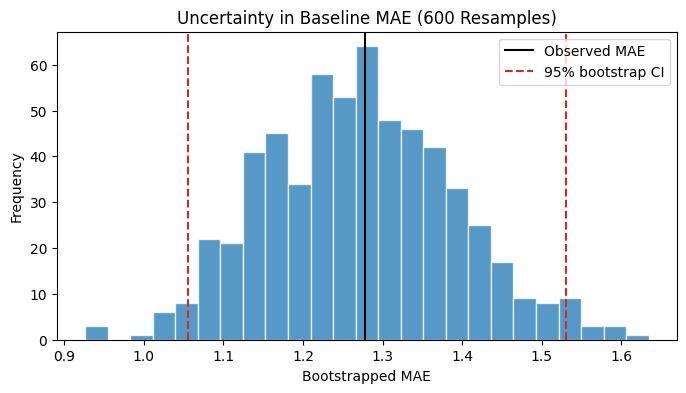

In [11]:
bm = bootstrap_metric(y, df2['y_hat'].values, mae, n_boot=600, seed=111)
print(f"MAE = {bm['estimate']:.3f}; 95% bootstrap CI = [{bm['lo']:.3f}, {bm['hi']:.3f}]")
plt.figure(figsize=(8, 4))
plt.hist(bm['samples'], bins=25, alpha=0.75, edgecolor='white')
plt.axvline(bm['estimate'], color='black', label='Observed MAE')
plt.axvline(bm['lo'], color='tab:red', linestyle='--', label='95% bootstrap CI')
plt.axvline(bm['hi'], color='tab:red', linestyle='--')
plt.xlabel('Bootstrapped MAE')
plt.ylabel('Frequency')
plt.title('Uncertainty in Baseline MAE (600 Resamples)')
plt.legend(); plt.show()

## Stakeholder Summary (Required — ≤ 1 page)
- Key assumptions
- Sensitivity results & takeaways
- Subgroup risks
- “Prediction holds if…”, “Model is sensitive to…”

### Stakeholder summary

**Decision headline.** The baseline captures the main linear relationship (slope 2.13), but its predictions have meaningful uncertainty: MAE is **1.278** with a 95% bootstrap interval of **[1.055, 1.531]** from 600 resamples. It is suitable for directional planning and comparisons near the observed data range, not for precise point commitments.

**Assumptions and sensitivity.** The result holds if the relationship remains approximately linear, the missing-feature rate stays near the observed 5%, and future observations resemble the current segment mix and feature range. The average Gaussian and bootstrap confidence-band widths are 0.920 and 0.791, respectively; their difference shows that uncertainty depends on the distributional method, so the distribution-free bootstrap is an important check on the Gaussian result. Mean and median imputation give nearly identical slopes and MAEs (1.278 versus 1.284), so the choice between those two fill rules is not material here. Dropping missing rows lowers in-sample MAE to 1.065, but it also removes nine observations; this apparent improvement is sensitive to the assumption that missingness is harmless and may not transfer if missing values are systematic.

**Hidden subgroup risk.** Segment C is the clearest failure point: its MAE is **1.827**, compared with **1.142** for A and **0.989** for B, and its residual spread is also substantially larger. Aggregate MAE therefore hides weaker reliability for C. Segment-level decisions should carry wider tolerances, and the model should not be presented as equally accurate across customers or cases.

**Recommendation.** Use the model only with an uncertainty range and report segment-level performance alongside the aggregate. Monitor missingness, segment mix, residual spread, and observations outside the training range. Collect more Segment C data and test segment interactions or separate models. Refit or pause use if missingness rises materially above 5%, Segment C performance remains unstable, or bootstrap intervals widen beyond the decision's acceptable error tolerance.